In [1]:
from spyplotter import Spectrum
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.coordinates import SpectralQuantity, SpectralCoord
%matplotlib widget

# Initialization of a Spectrum

You can either create a spectrum from two arrays directly:

In [2]:
spectrum = Spectrum([1,2,3],[5,6,7])

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


or read it from a *.plot file from a PoWR model:

In [3]:
spectrum_contplines = Spectrum.from_powr(filepath='../tests/test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/wruniq.plot',keywords=['EMERGENT'],dataset=3)

spyplotter.spectrum - INFO - Flux calibrated spectrum at 10 pc. Thus using erg / (Angstrom s cm2) as y unit.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed


Dataset 3 corresponds to the spectrum that contains continuum + lines.

You can also read an observed spectrum from a table file (e.g. csv) with numpy or pandas and then create a Spectrum object:

In [4]:
filename = '../tests/test_data/simulated_spectrum.csv'
data_sim = np.loadtxt(filename, skiprows=1,delimiter=',')
spectrum_sim = Spectrum(data_sim[:,0],data_sim[:,1])

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


or read from a file containing a xy table:

In [5]:
spectrum_sim = Spectrum.from_file(filename,skiprows=1,delimiter=',')

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


# Plot spectrum

When plotting the spectrum, you can choose the flux units and the units for the x-axis by using the common astropy units:

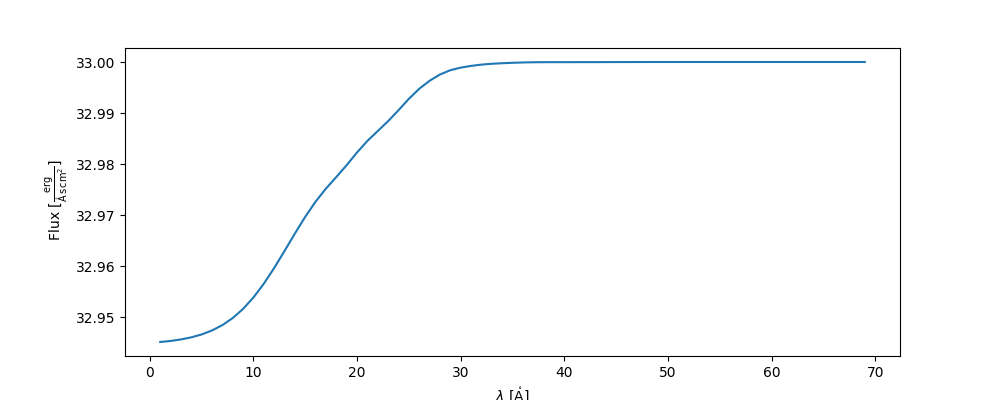

In [6]:
fig = spectrum_contplines.plot(x_unit=u.AA);

You can easily plot another normalized spectrum:

spyplotter.spectrum - INFO - No flux unit specified and no signs for y units detected. Thus assuming normalized spectum.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


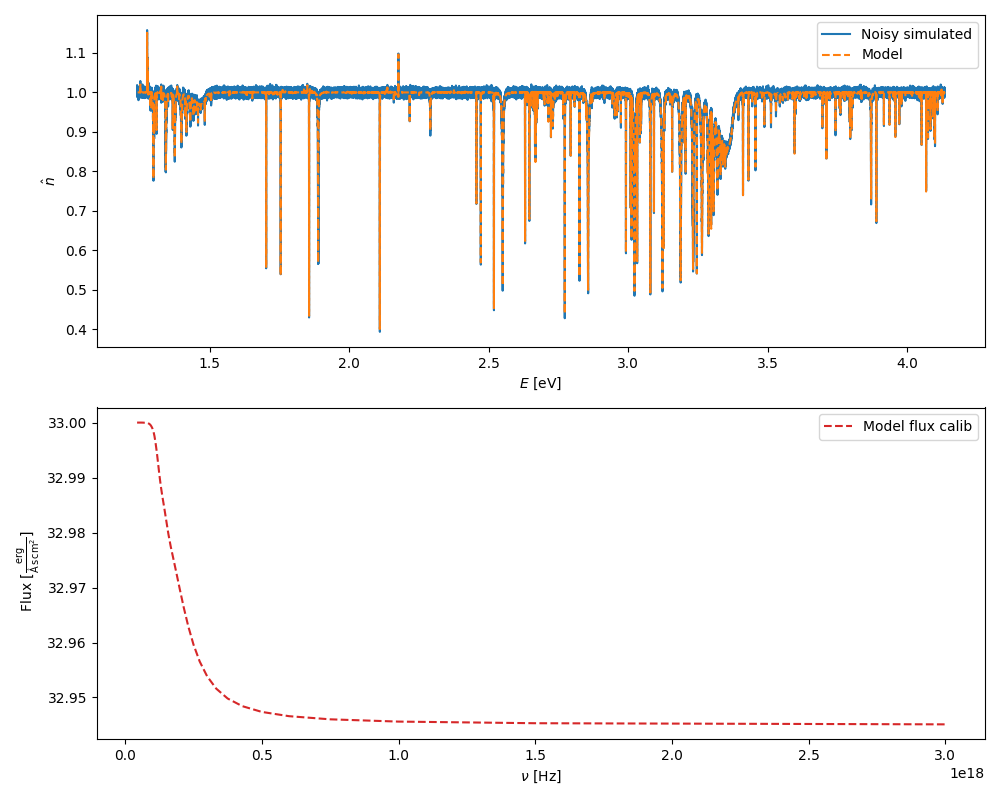

In [7]:
spectrum_norm = Spectrum.from_powr(filepath='../tests/test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/formal.plot',keywords=['OPT'],dataset=1)

fig,ax = plt.subplots(2,1,figsize=(10,8))

spectrum_sim.plot(x_unit=u.eV,ax=ax[0],color='C00',label='Noisy simulated');
spectrum_norm.plot(x_unit=u.eV,ax=ax[0],ls='--',color='C01',label='Model');
spectrum_contplines.plot(x_unit=u.Hz,ax=ax[1],ls='--',color='C03',label='Model flux calib');

for i in range(2):
    ax[i].legend()
plt.tight_layout()

If you want to zoom into specific regions:

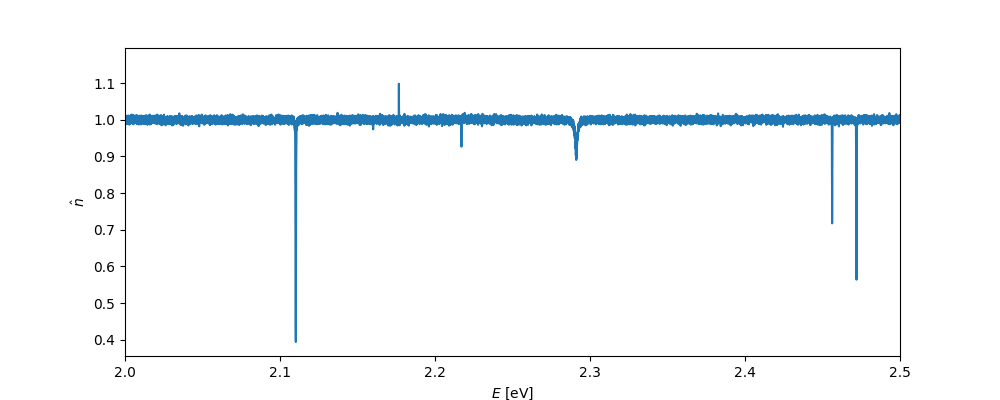

In [8]:
spectrum_sim.plot(x_unit=u.eV,color='C00',label='Noisy simulated',interval=[2,2.5]);

If you want to zoom multiple regions, use zoom_plot and a list of intervals. You can use the helper function generate_intervals to get equally spaced intervals.

[[2.0, 2.25], [2.25, 2.5], [2.5, 2.75], [2.75, 3.0]]


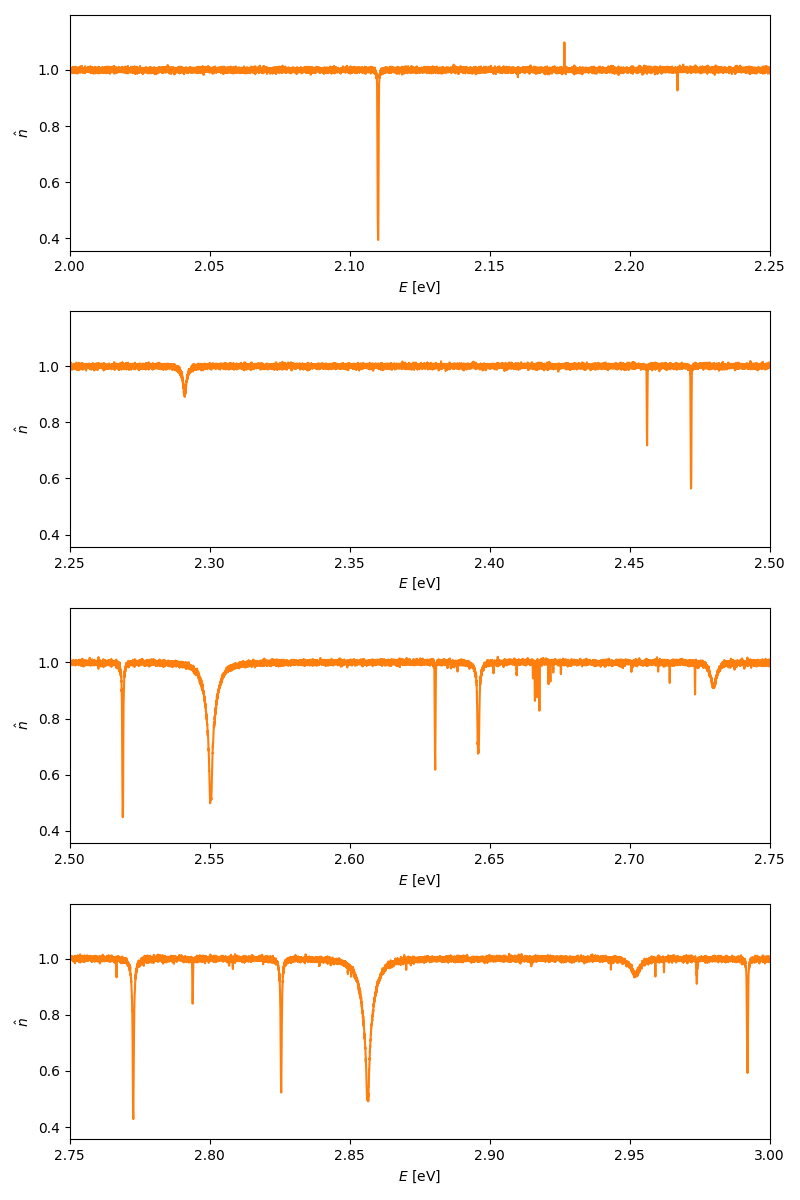

In [9]:
from spyplotter.spec_tools import generate_intervals
intervals = generate_intervals(2,3,4)
print(intervals)

spectrum_sim.zoom_plot(x_unit=u.eV,intervals=intervals,fig_height=3,fig_width=8,color='C01');
plt.tight_layout()

# Convert whole spectrum into other units

In [10]:
spectrum_sim.x_unit

Unit("Angstrom")

In [11]:
spectrum_sim.convert_units(x_unit=u.nm)

In [12]:
spectrum_sim.x_unit

Unit("nm")

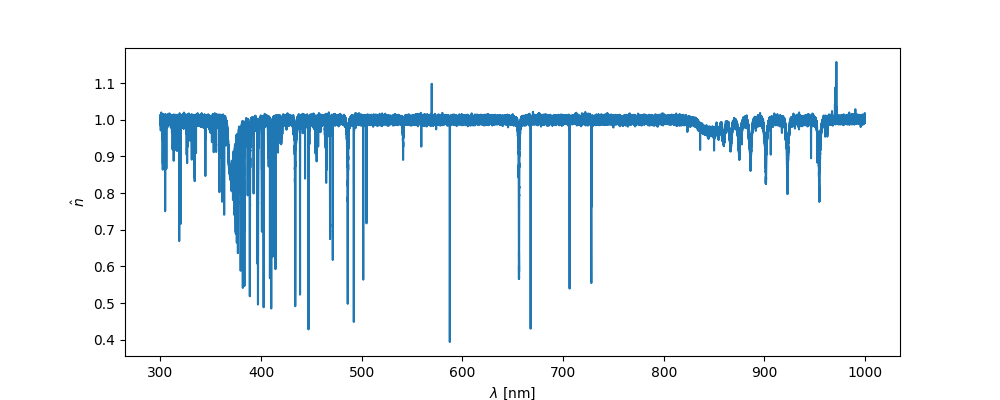

In [13]:
spectrum_sim.plot();

# Apply velocity shift

You can hoose if you want to create a new spectrum with an applied spectrum or overwrite the current spectrum.

In the following example, a new spectrum object is created with the same characteristics as before, only that it has a shifted spectrum given by the radial velocity.

spyplotter.spectrum - INFO - No unit for vrad specified. Thus assuming km/s.
spyplotter.spectrum - INFO - Keeping units of x: nm
spyplotter.spectrum - INFO - Keeping units of y: 


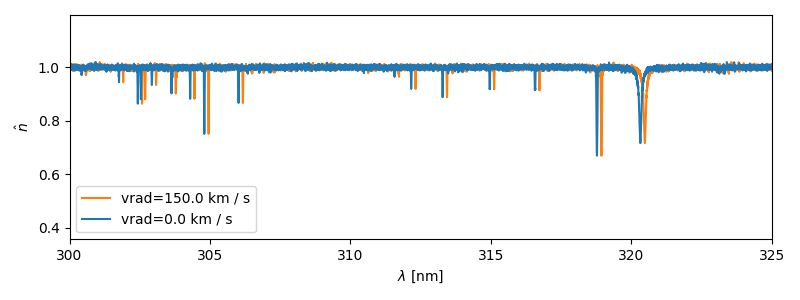

In [14]:
spectrum_shifted=spectrum_sim.apply_shift_vrad(150.,overwrite=False)
fig = spectrum_shifted.plot(x_unit=u.nm,interval=[300,325],fig_height=3,fig_width=8,color='C01',label=f'vrad={spectrum_shifted.vrad}');
ax = fig.get_axes()
spectrum_sim.plot(ax=ax[0],x_unit=u.nm,interval=[300,325],color='C00',label=f'vrad={spectrum_sim.vrad}');
ax[0].legend()
plt.tight_layout()

# Convert to velocity space

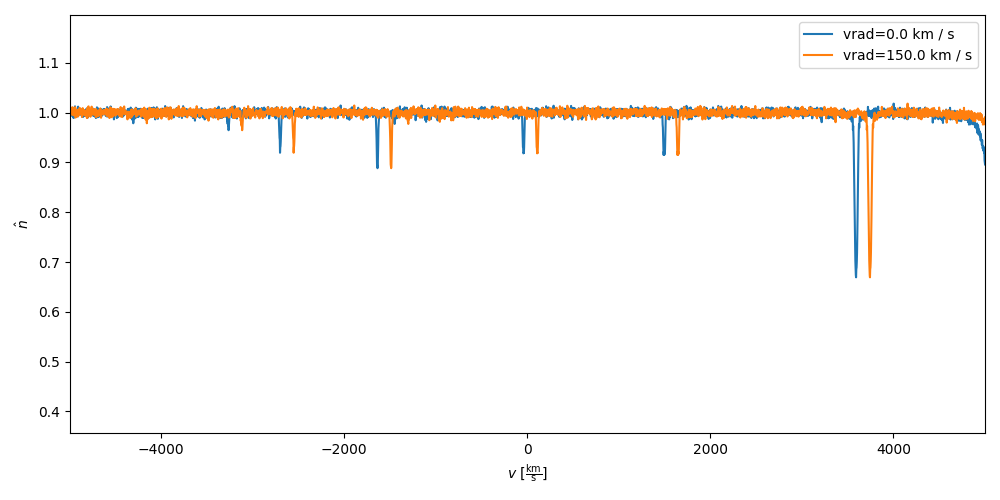

In [21]:
fig, ax = plt.subplots(figsize=(10,5))

#without radial shift
spectrum_sim.plot_velocity(x_rest=315*u.nm,interval=[-5000,5000],ax=ax,label=f'vrad={spectrum_sim.vrad}');

#with radial shift -> does not change whole spectrum, only for plotting
vrad = 150 * u.km / u.s
spectrum_sim.plot_velocity(x_rest=315*u.nm,vrad=vrad,ax=ax,color='C01',label=f'vrad={vrad}');

ax.legend()
plt.tight_layout()

# Save spectrum to file

In [30]:
a = 0 * u.AA
a == 0

True